In [1]:
# import libraries:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# Dataset fetching
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
census_income=fetch_ucirepo(id=20)
X=census_income.data.features
y=census_income.data.targets

X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [3]:
X.info()
X.shape

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
dtypes: int64(6), str(8)
memory usage: 5.2 MB


(48842, 14)

In [4]:
X.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [5]:
# Unique values in categorical column
categorical_columns=X.select_dtypes(include=['object']).columns
for i in categorical_columns:
    print(f"Unique values in '{i}': {X[i].unique()}\n")

Unique values in 'workclass': <StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked',
                nan]
Length: 10, dtype: str

Unique values in 'education': <StringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str

Unique values in 'marital-status': <StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

Unique values in 'occupation': <StringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service'

In [6]:
# Preprocessing: Handling missing values and '?' value
null_columns=[]
for i in X.columns:
    if X[i].isnull().sum()>0:
        null_columns.append(i)
print(f"Columns with missing values: {null_columns}")

null_categories_col=[]
for i in null_columns:
    if X[i].dtype=='object':
        null_categories_col.append(i)
print(f"Categorical columns with missing values: {null_categories_col}")

for i in null_categories_col:
    X.fillna({i:X[i].mode()[0]}, inplace=True)

X['workclass']=X['workclass'].replace({'?':'Unknown'})
X['occupation']=X['occupation'].replace({'?':'Unknown'})

X.isnull().sum()


Columns with missing values: ['workclass', 'occupation', 'native-country']
Categorical columns with missing values: []


age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [7]:
X.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
# Preprocessing: Subtitute Country name with continent name
def get_continent(country):
    continent_mapping = {
    'United-States': 'North America', 'Cuba': 'North America', 'Jamaica': 'North America',
    'India': 'Asia', 'Mexico': 'North America', 'South': 'Asia', 'Puerto-Rico': 'North America',
    'Honduras': 'North America', 'England': 'Europe', 'Canada': 'North America', 'Germany': 'Europe',
    'Iran': 'Asia', 'Philippines': 'Asia', 'Italy': 'Europe', 'Poland': 'Europe', 'Columbia': 'South America',
    'Cambodia': 'Asia', 'Thailand': 'Asia', 'Ecuador': 'South America', 'Laos': 'Asia', 'Taiwan': 'Asia',
    'Haiti': 'North America', 'Portugal': 'Europe', 'Dominican-Republic': 'North America',
    'El-Salvador': 'North America', 'France': 'Europe', 'Guatemala': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'Yugoslavia': 'Europe',
    'Peru': 'South America', 'Outlying-US(Guam-USVI-etc)': 'North America',
    'Scotland': 'Europe', 'Trinadad&Tobago': 'North America',
    'Greece': 'Europe', 'Nicaragua': 'North America', 'Vietnam': 'Asia',
    'Hong': 'Asia', 'Ireland': 'Europe','Hungary': 'Europe', 'Holand-Netherlands': 'Europe'
    }
    try:
        return continent_mapping[country]
    except:
        return 'Unknown'
X['native-country'] = X['native-country'].apply(get_continent)
df=X.copy()
# Preprocessing: Sacling the ages:
num_col=['age','fnlwgt','capital-gain','hours-per-week','capital-loss','education-num']
min_max_scaler=MinMaxScaler()
X[num_col]=min_max_scaler.fit_transform(X[num_col])
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,0.044131,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,North America
1,0.452055,Self-emp-not-inc,0.048052,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,North America
2,0.287671,Private,0.137581,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,North America
3,0.493151,Private,0.150486,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,North America
4,0.150685,Private,0.220635,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,North America


In [9]:
# Preprocessing: One Hot Encoding:
X_encoded=pd.get_dummies(X, columns=categorical_columns,dtype=int,drop_first=True)
print(X_encoded.head())
X_encoded.shape

        age    fnlwgt  education-num  capital-gain  capital-loss  \
0  0.301370  0.044131       0.800000       0.02174           0.0   
1  0.452055  0.048052       0.800000       0.00000           0.0   
2  0.287671  0.137581       0.533333       0.00000           0.0   
3  0.493151  0.150486       0.400000       0.00000           0.0   
4  0.150685  0.220635       0.800000       0.00000           0.0   

   hours-per-week  workclass_Local-gov  workclass_Never-worked  \
0        0.397959                    0                       0   
1        0.122449                    0                       0   
2        0.397959                    0                       0   
3        0.397959                    0                       0   
4        0.397959                    0                       0   

   workclass_Private  workclass_Self-emp-inc  ...  relationship_Wife  \
0                  0                       0  ...                  0   
1                  0                       0  ... 

(48842, 63)

In [10]:
# Preprocessing: Target variable encoding
print(y['income'].unique())

y['income'] = y['income'].map({'>50K': 1, '<=50K': 0 ,'<=50K.':0, '>50K.':1})

y.value_counts()

<StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str


income
0         37155
1         11687
Name: count, dtype: int64

Text(0.5, 1.0, 'Correlation Matrix of Features')

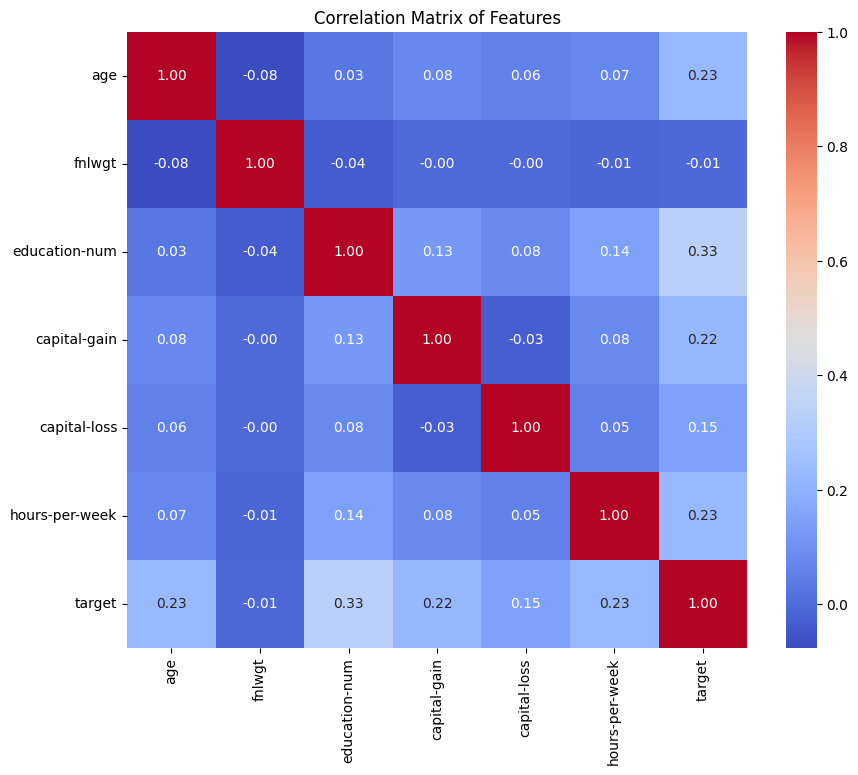

In [11]:
# EDA:
# Visualization: Correaltion with target
plt.figure(figsize=(10, 8))
X_target=X
X_target['target']=y['income']
corr_matrix=X_target.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')


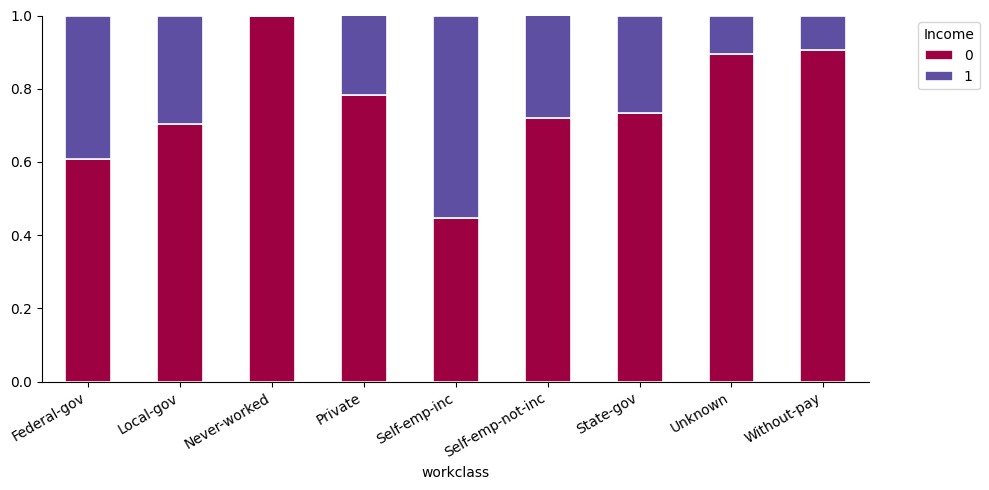

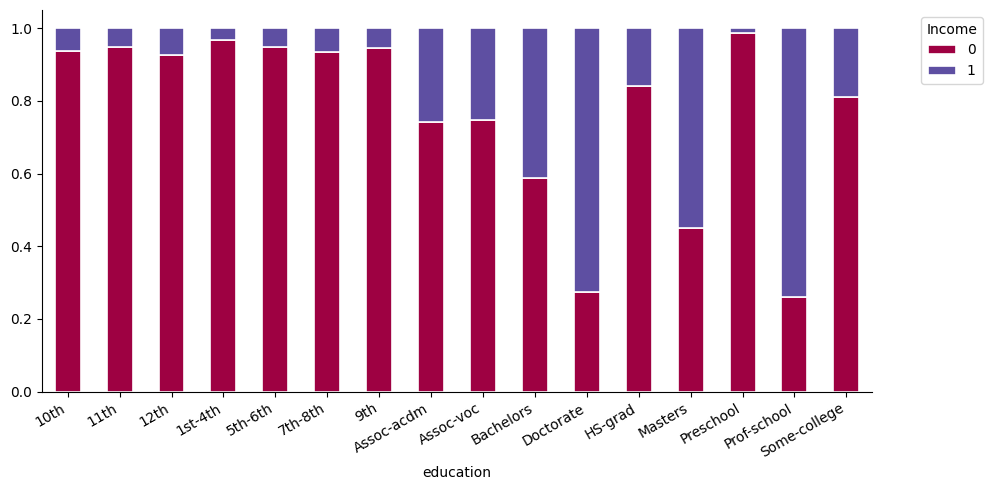

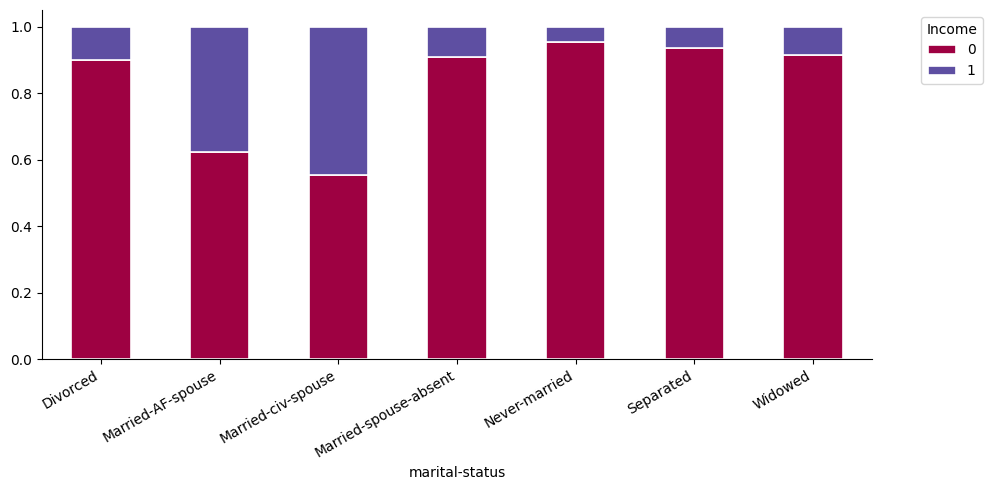

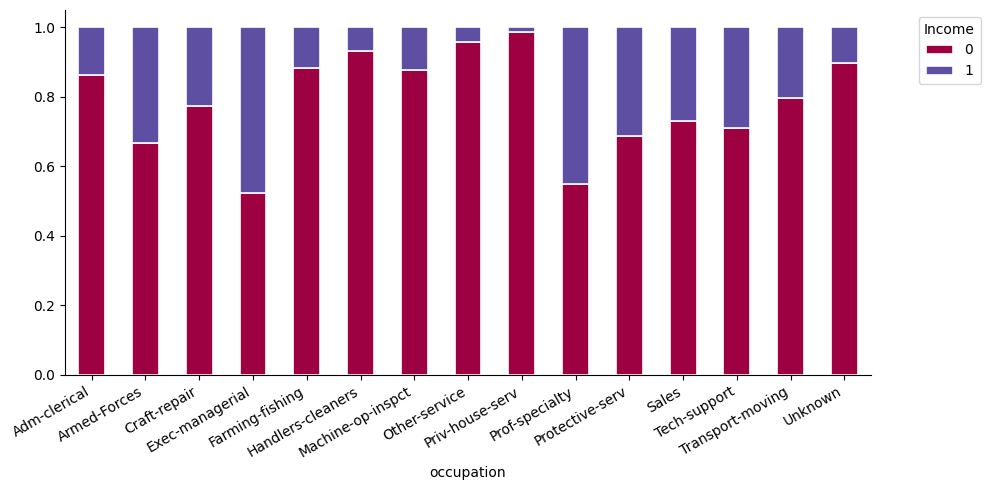

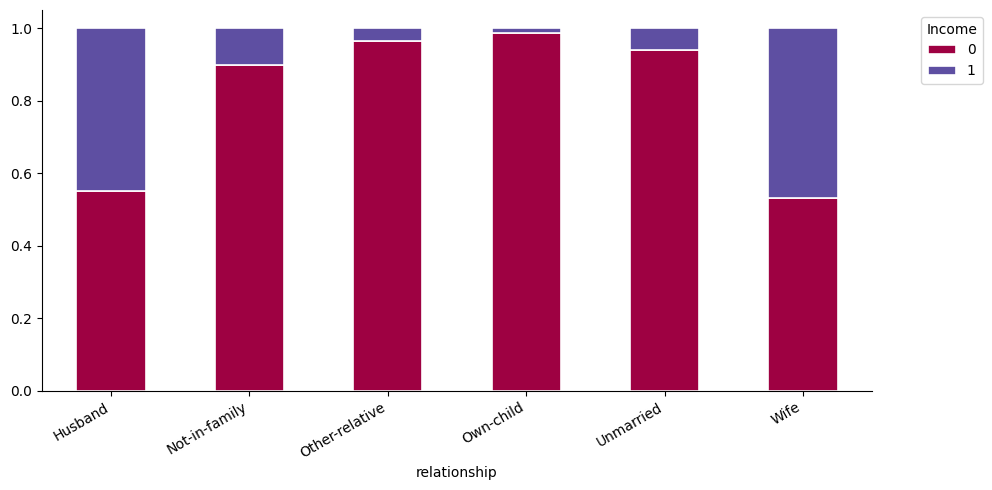

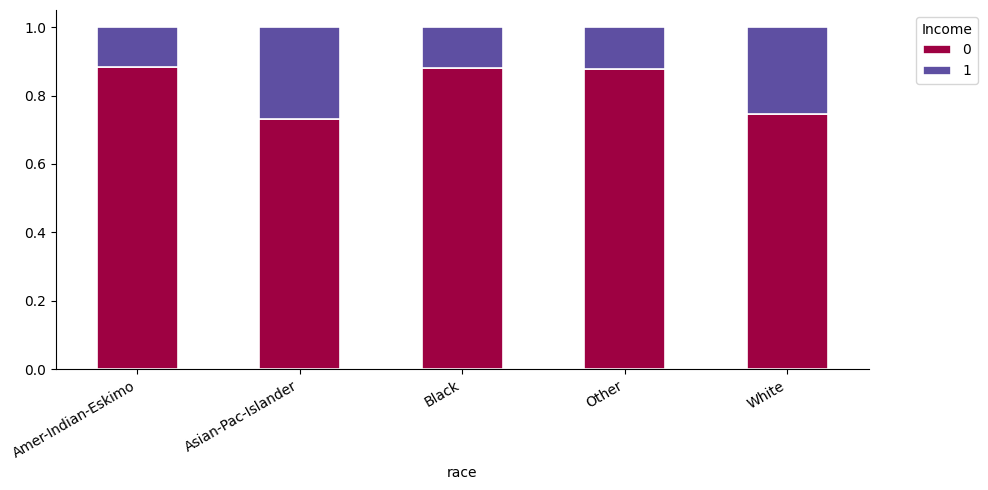

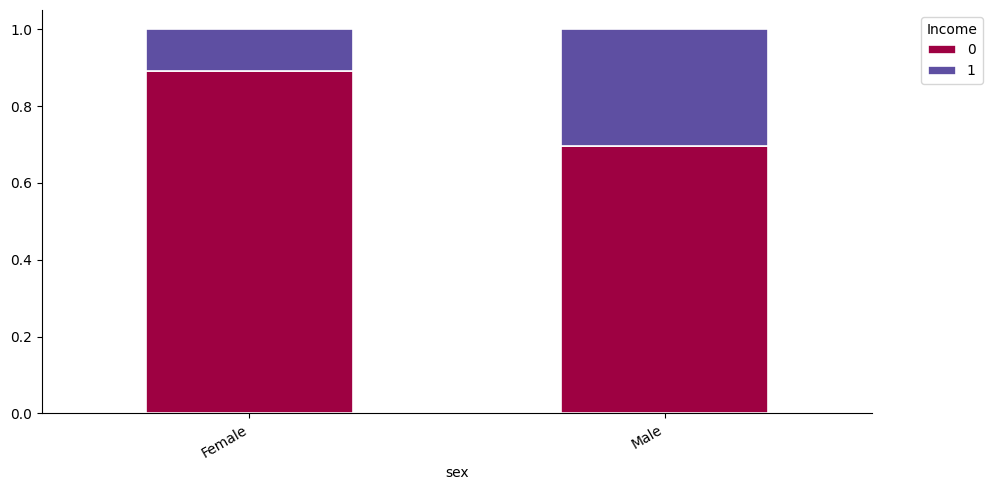

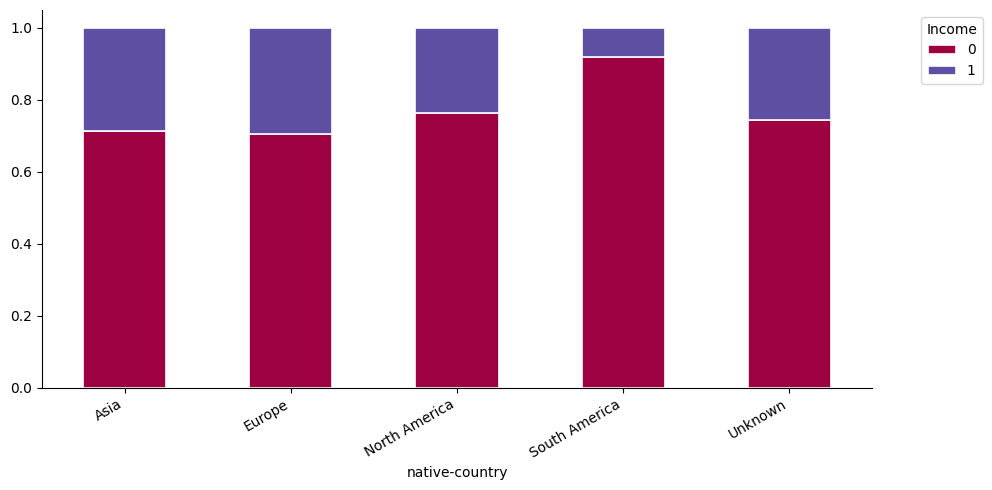

In [12]:
# EDA
# Crosstab representation:
for c in categorical_columns:
    ct = pd.crosstab(X[c], y['income'], normalize='index')
    ax = ct.plot(kind='bar', stacked=True, figsize=(10, 5),colormap='Spectral',
        edgecolor='white', linewidth=1.2)
    plt.xticks(rotation=30,ha='right')
    plt.legend(title='Income', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


In [13]:
X.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,target
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,0.296487,0.120004,0.605206,0.010791,0.020088,0.402269,0.239282
std,0.187815,0.071445,0.171398,0.074521,0.092517,0.126443,0.426649
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.071216,0.533333,0.000000,0.000000,0.397959,0.000000
50%,0.273973,0.112210,0.600000,0.000000,0.000000,0.397959,0.000000
75%,0.424658,0.152462,0.733333,0.000000,0.000000,0.448980,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Training Portion:
Accuracy-> 0.85
Precision-> 0.73
Recall-> 0.59
F1-score-> 0.65


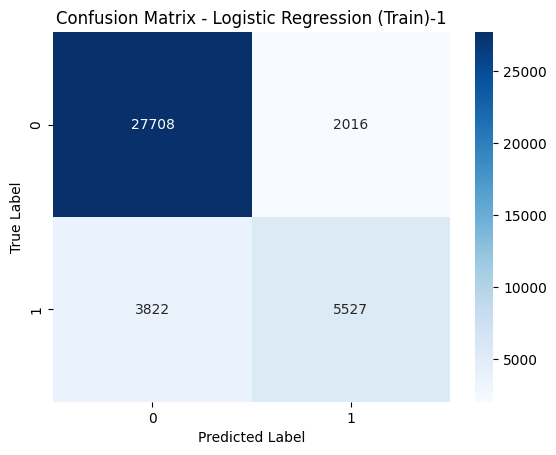

Testing Portion
Accuracy-> 0.85
Precision-> 0.73
Recall-> 0.59
F1-score-> 0.65


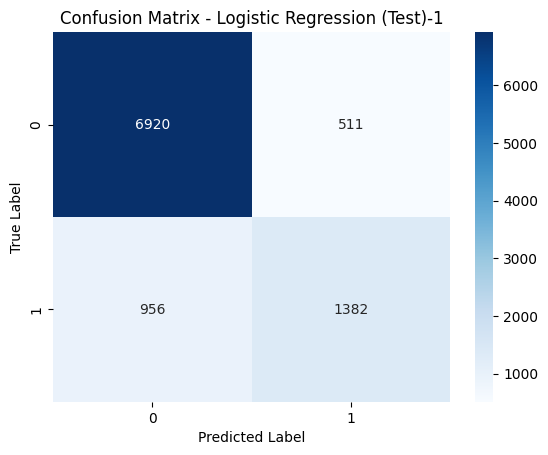

In [14]:
# Train Test Spliting: 0.2
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2,random_state=42,stratify=y)

# Logistics Regression:
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)

y_pred=log_reg.predict(X_train)
cm=confusion_matrix(y_train,y_pred)
print("Training Portion:")
print("Accuracy->",np.round(accuracy_score(y_train,y_pred),2))
print("Precision->",np.round(precision_score(y_train,y_pred),2))
print("Recall->",np.round(recall_score(y_train,y_pred),2))
print("F1-score->",np.round(f1_score(y_train,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression (Train)-1')
plt.show()

y_pred=log_reg.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print("Testing Portion")
print("Accuracy->",np.round(accuracy_score(y_test,y_pred),2))
print("Precision->",np.round(precision_score(y_test,y_pred),2))
print("Recall->",np.round(recall_score(y_test,y_pred),2))
print("F1-score->",np.round(f1_score(y_test,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression (Test)-1')
plt.show()


Training Portion:
Accuracy-> 0.85
Precision-> 0.73
Recall-> 0.59
F1-score-> 0.65


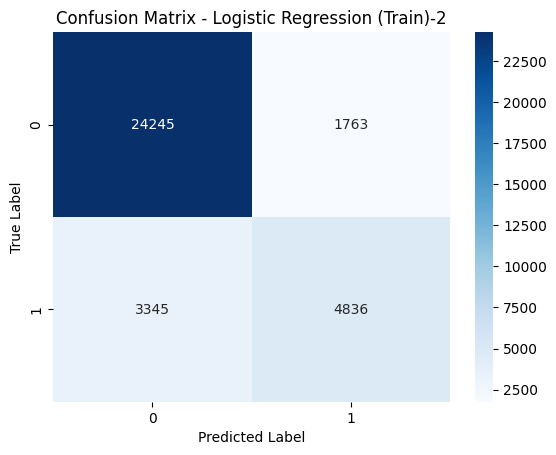

Testing Portion
Accuracy-> 0.85
Precision-> 0.73
Recall-> 0.59
F1-score-> 0.65


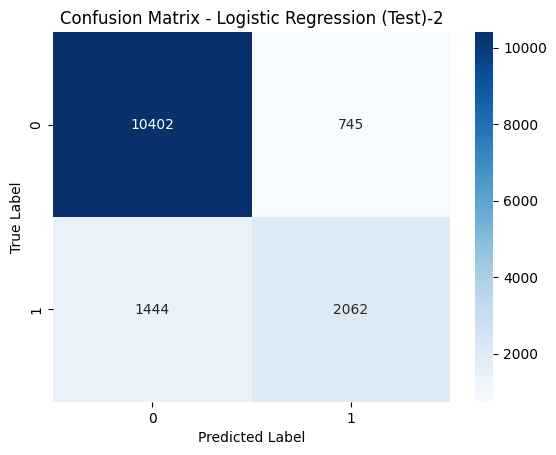

In [15]:
# Train Test Spliting: 0.3
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.3,random_state=42,stratify=y)

# Logistics Regression:
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)

y_pred=log_reg.predict(X_train)
cm=confusion_matrix(y_train,y_pred)
print("Training Portion:")
print("Accuracy->",np.round(accuracy_score(y_train,y_pred),2))
print("Precision->",np.round(precision_score(y_train,y_pred),2))
print("Recall->",np.round(recall_score(y_train,y_pred),2))
print("F1-score->",np.round(f1_score(y_train,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression (Train)-2')
plt.show()

y_pred=log_reg.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print("Testing Portion")
print("Accuracy->",np.round(accuracy_score(y_test,y_pred),2))
print("Precision->",np.round(precision_score(y_test,y_pred),2))
print("Recall->",np.round(recall_score(y_test,y_pred),2))
print("F1-score->",np.round(f1_score(y_test,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression (Test)-2')
plt.show()


Training Portion:
Accuracy-> 0.6
Precision-> 0.37
Recall-> 0.94
F1-score-> 0.53


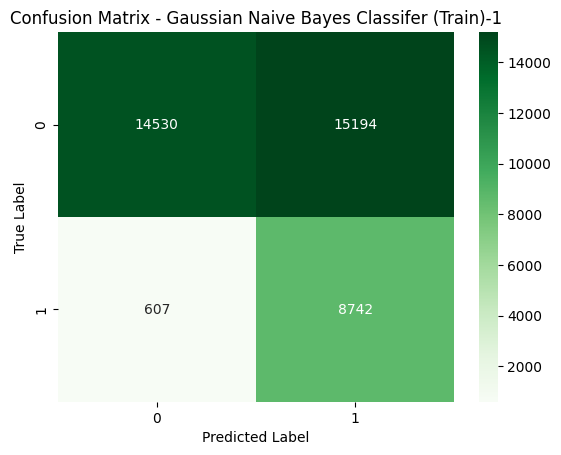

Testing Portion
Accuracy-> 0.59
Precision-> 0.36
Recall-> 0.94
F1-score-> 0.52


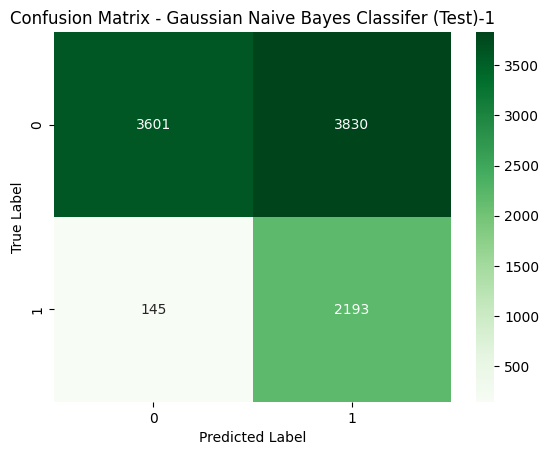

In [16]:
# Train Test Spliting: 0.2
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2,random_state=42,stratify=y)

# Naive Bayes Classifier
gnb=GaussianNB()
gnb.fit(X_train,y_train)
y_pred=gnb.predict(X_train)
cm=confusion_matrix(y_train,y_pred)
print("Training Portion:")
print("Accuracy->",np.round(accuracy_score(y_train,y_pred),2))
print("Precision->",np.round(precision_score(y_train,y_pred),2))
print("Recall->",np.round(recall_score(y_train,y_pred),2))
print("F1-score->",np.round(f1_score(y_train,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Greens', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gaussian Naive Bayes Classifer (Train)-1')
plt.show()

y_pred=gnb.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print("Testing Portion")
print("Accuracy->",np.round(accuracy_score(y_test,y_pred),2))
print("Precision->",np.round(precision_score(y_test,y_pred),2))
print("Recall->",np.round(recall_score(y_test,y_pred),2))
print("F1-score->",np.round(f1_score(y_test,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Greens', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gaussian Naive Bayes Classifer (Test)-1')
plt.show()


Training Portion:
Accuracy-> 0.6
Precision-> 0.37
Recall-> 0.94
F1-score-> 0.53


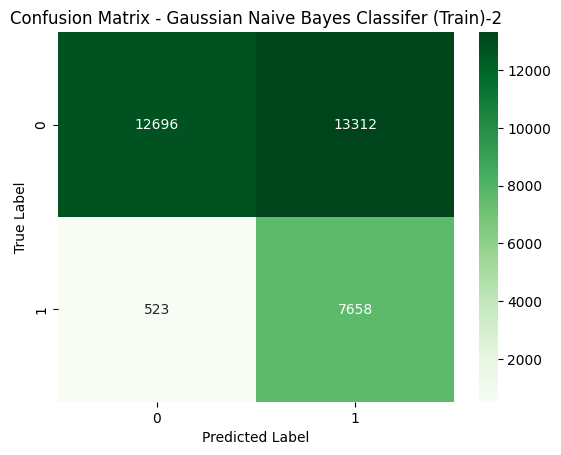

Testing Portion
Accuracy-> 0.59
Precision-> 0.36
Recall-> 0.94
F1-score-> 0.52


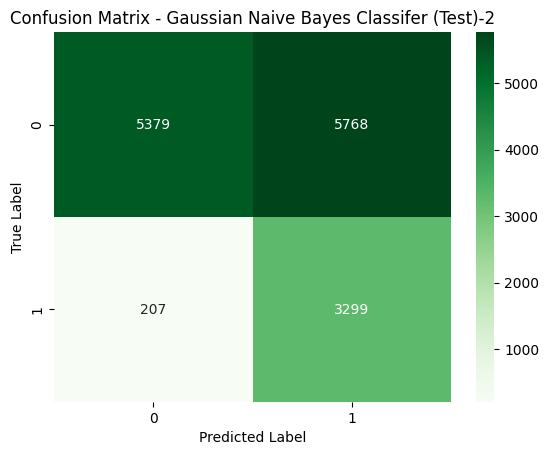

In [17]:
# Train Test Spliting: 0.3
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.3,random_state=42,stratify=y)

# Naive Bayes Classifier
gnb=GaussianNB()
gnb.fit(X_train,y_train)
y_pred=gnb.predict(X_train)
cm=confusion_matrix(y_train,y_pred)
print("Training Portion:")
print("Accuracy->",np.round(accuracy_score(y_train,y_pred),2))
print("Precision->",np.round(precision_score(y_train,y_pred),2))
print("Recall->",np.round(recall_score(y_train,y_pred),2))
print("F1-score->",np.round(f1_score(y_train,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Greens', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gaussian Naive Bayes Classifer (Train)-2')
plt.show()

y_pred=gnb.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print("Testing Portion")
print("Accuracy->",np.round(accuracy_score(y_test,y_pred),2))
print("Precision->",np.round(precision_score(y_test,y_pred),2))
print("Recall->",np.round(recall_score(y_test,y_pred),2))
print("F1-score->",np.round(f1_score(y_test,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Greens', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gaussian Naive Bayes Classifer (Test)-2')
plt.show()


Training Portion:
Accuracy-> 0.84
Precision-> 0.76
Recall-> 0.51
F1-score-> 0.61


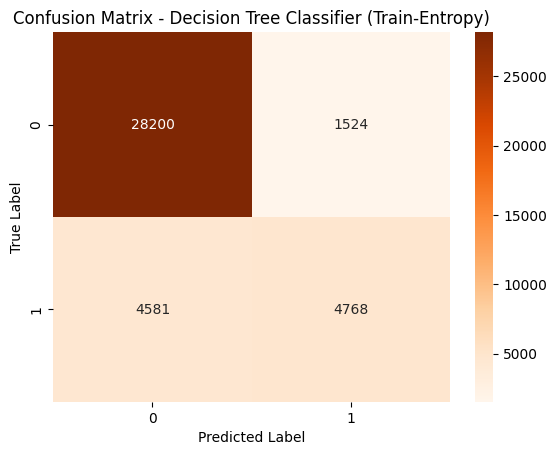

Testing Portion
Accuracy-> 0.85
Precision-> 0.76
Recall-> 0.52
F1-score-> 0.62


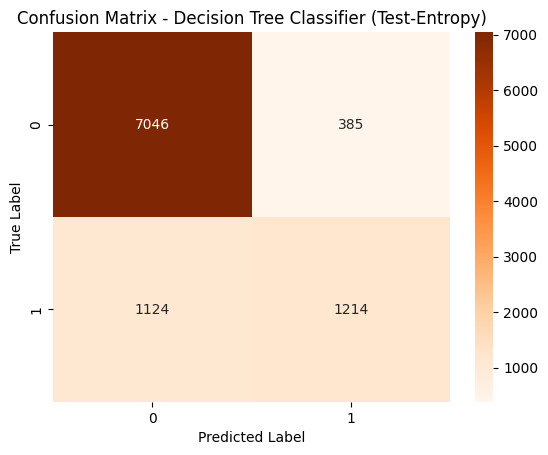

In [18]:
# Train Test Spliting: 0.2
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2,random_state=42,stratify=y)

# Decision Tree classifier

dt=DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_train)
cm=confusion_matrix(y_train,y_pred)
print("Training Portion:")
print("Accuracy->",np.round(accuracy_score(y_train,y_pred),2))
print("Precision->",np.round(precision_score(y_train,y_pred),2))
print("Recall->",np.round(recall_score(y_train,y_pred),2))
print("F1-score->",np.round(f1_score(y_train,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Oranges', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Classifier (Train-Entropy)')
plt.show()

y_pred=dt.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print("Testing Portion")
print("Accuracy->",np.round(accuracy_score(y_test,y_pred),2))
print("Precision->",np.round(precision_score(y_test,y_pred),2))
print("Recall->",np.round(recall_score(y_test,y_pred),2))
print("F1-score->",np.round(f1_score(y_test,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Oranges', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Classifier (Test-Entropy)')
plt.show()


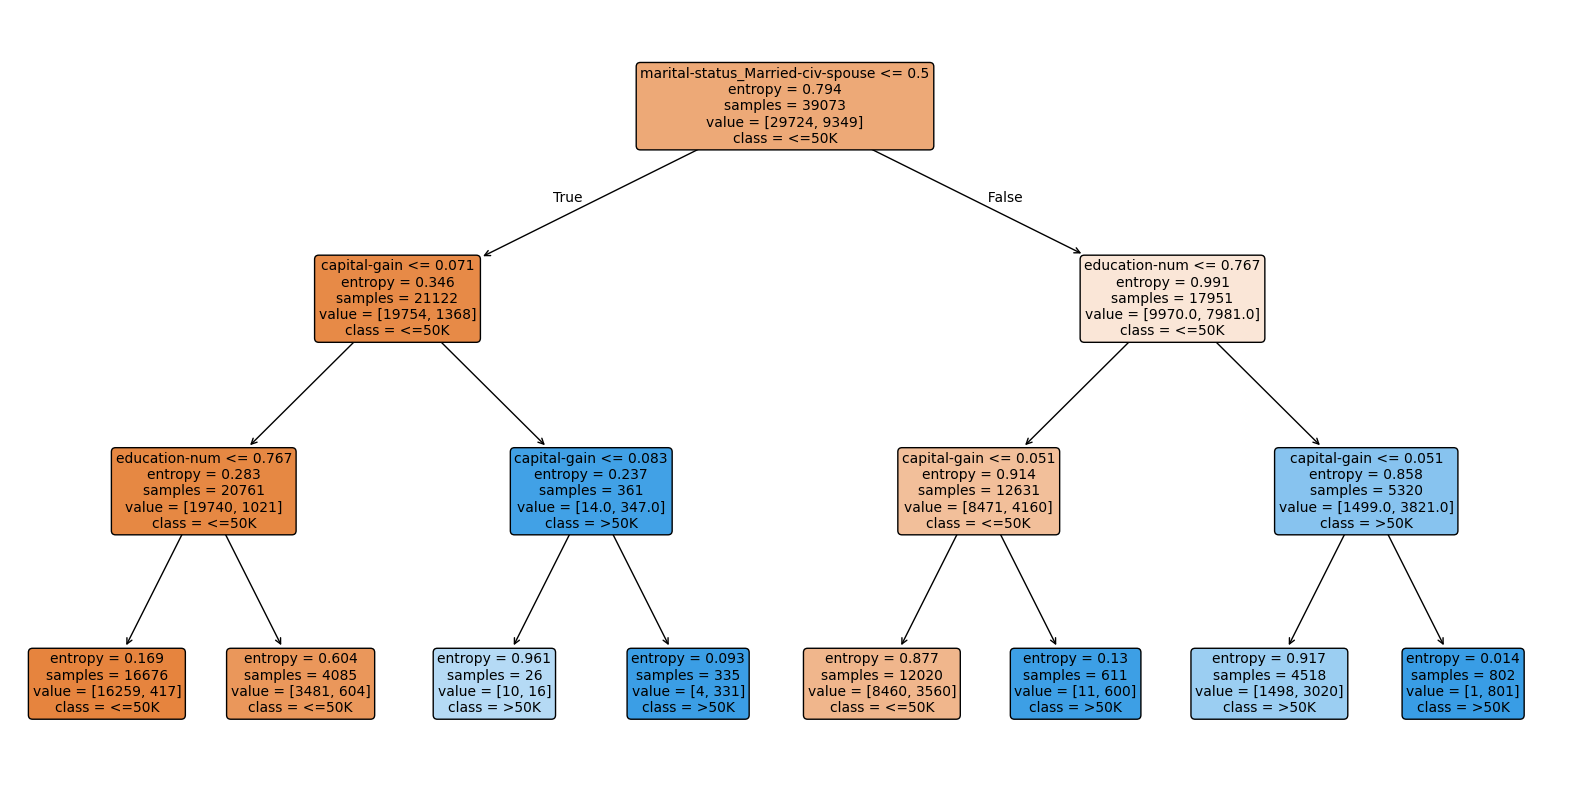

In [19]:
plt.figure(figsize=(20, 10))

plot_tree(dt,
          feature_names=X_encoded.columns,
          class_names=['<=50K', '>50K'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.show()

Training Portion:
Accuracy-> 0.84
Precision-> 0.76
Recall-> 0.51
F1-score-> 0.61


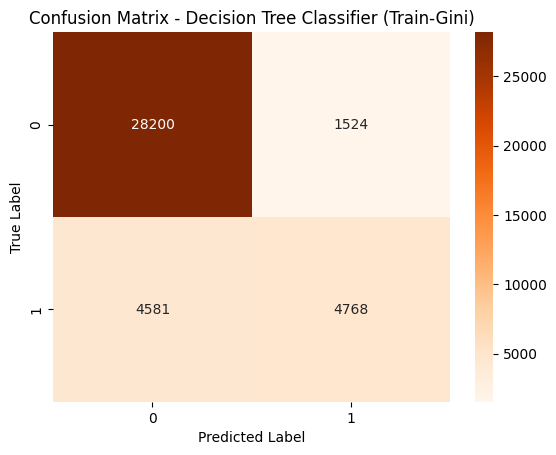

Testing Portion
Accuracy-> 0.85
Precision-> 0.76
Recall-> 0.52
F1-score-> 0.62


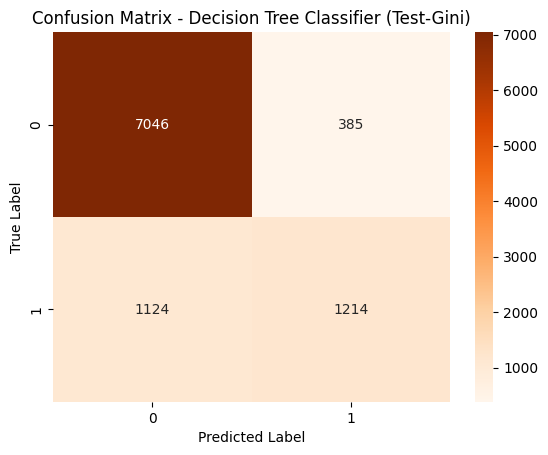

In [20]:
# Decision Tree classifier

dt=DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_train)
cm=confusion_matrix(y_train,y_pred)
print("Training Portion:")
print("Accuracy->",np.round(accuracy_score(y_train,y_pred),2))
print("Precision->",np.round(precision_score(y_train,y_pred),2))
print("Recall->",np.round(recall_score(y_train,y_pred),2))
print("F1-score->",np.round(f1_score(y_train,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Oranges', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Classifier (Train-Gini)')
plt.show()

y_pred=dt.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print("Testing Portion")
print("Accuracy->",np.round(accuracy_score(y_test,y_pred),2))
print("Precision->",np.round(precision_score(y_test,y_pred),2))
print("Recall->",np.round(recall_score(y_test,y_pred),2))
print("F1-score->",np.round(f1_score(y_test,y_pred),2))

sns.heatmap(cm, annot=True, cmap='Oranges', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Classifier (Test-Gini)')
plt.show()


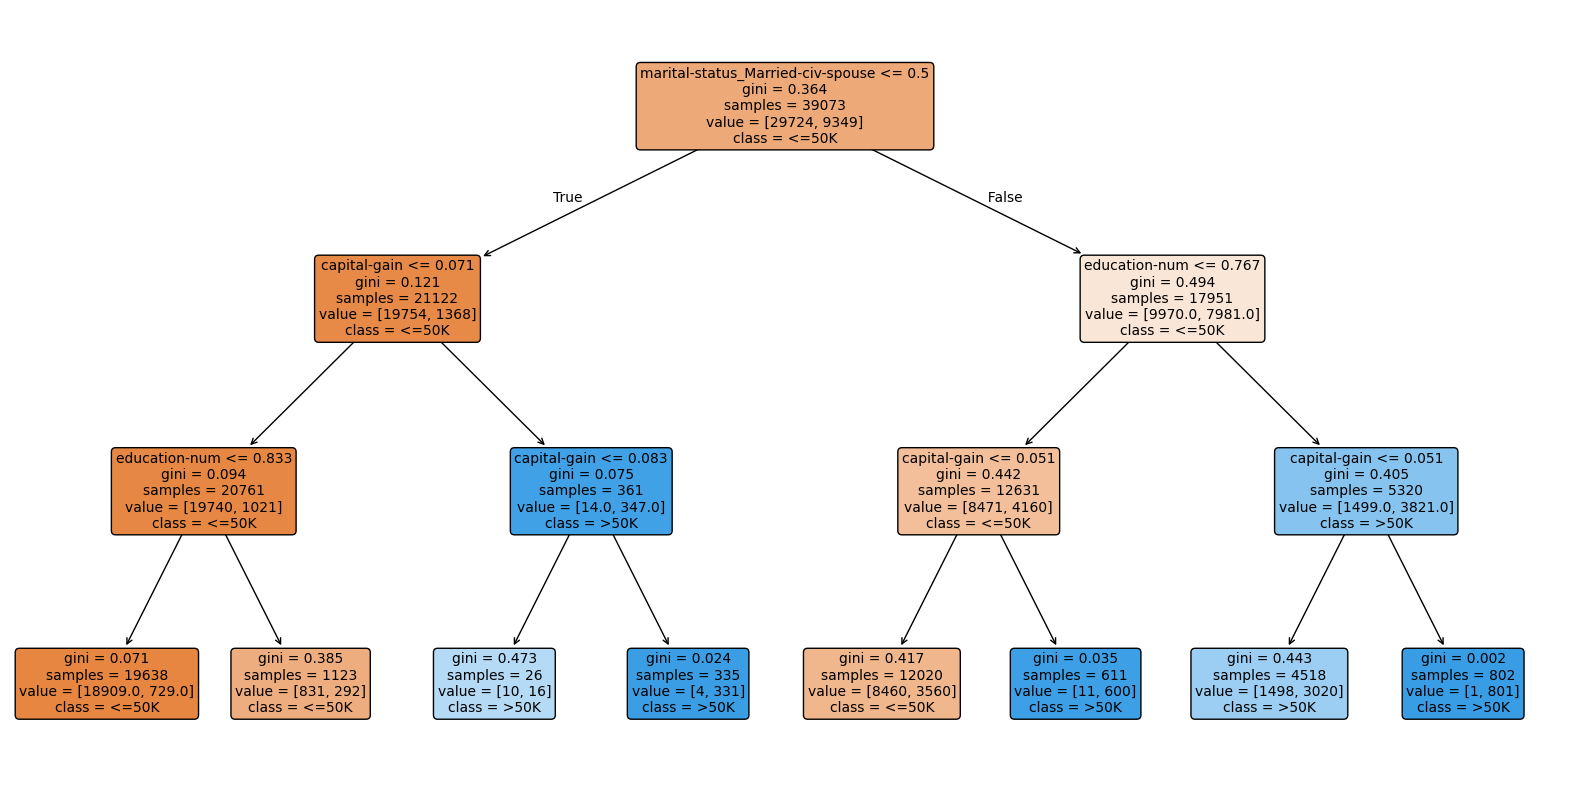

In [21]:
plt.figure(figsize=(20, 10))

plot_tree(dt,
          feature_names=X_encoded.columns,
          class_names=['<=50K', '>50K'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.show()

In [22]:
# Frequent Pattern Analysis and Apriori ALgorithm:
yy=y['income'].replace({1:'G50K', 0:'LE50K'})
df['income']=yy
df=df.drop(columns=['fnlwgt','education-num','capital-gain','capital-loss','hours-per-week'])
def Age(x):
    if x<=18:
        return 'Child'
    elif x>18 and x<=25:
        return 'Youth'
    elif x>25 and x<40:
      return 'Adult'
    else:
        return 'Senior'
    
# Age Bining
df['age']=df['age'].apply(Age)
df.head()



,age,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,Adult,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,North America,LE50K
1,Senior,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,North America,LE50K
2,Adult,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,North America,LE50K
3,Senior,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,North America,LE50K
4,Adult,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,North America,LE50K


In [23]:
import random
random.seed(42)

dataset=[]
col=list(df.columns)

In [24]:
for i in range(len(df)):
    temp=[]
    random_col=random.choices(col,k=random.randint(2,len(col))) # random column choice
    random_col=list(set(random_col)) # unique column
    for j in random_col:
        temp.append(df.iloc[i][j])
    dataset.append(temp)

dataset=[[str(i) for i in row] for row in dataset]



In [25]:
for i in range(10):
  print(dataset[i],end='\n\n')

['Bachelors', 'Adult']

['Senior', 'North America', 'White']

['Male', 'Handlers-cleaners', 'Not-in-family', 'HS-grad', 'Adult', 'White']

['North America', 'Married-civ-spouse', 'Husband', 'Private', 'LE50K', 'Senior', 'Black']

['Married-civ-spouse']

['Female', 'North America', 'Married-civ-spouse', 'Wife', 'LE50K']

['Female', 'Senior', '9th', 'Not-in-family']

['Exec-managerial', 'North America', 'Married-civ-spouse']

['G50K', 'Masters', 'Never-married']

['Male', 'White', 'Private']



In [26]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules,fpgrowth

te=TransactionEncoder()
te_ary=te.fit(dataset).transform(dataset)
new_df=pd.DataFrame(te_ary, columns=te.columns_)

new_df.head()

,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Adm-clerical,Adult,Amer-Indian-Eskimo,...,Tech-support,Transport-moving,Unknown,Unmarried,White,Widowed,Wife,Without-pay,Youth,nan
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [27]:
frequent_itemsets=apriori(new_df, min_support=0.05, use_colnames=True)
print(frequent_itemsets.sort_values(by='support', ascending=False).to_string(index=False))
print(len(frequent_itemsets))

 support                                       itemsets
0.417919                     frozenset({North America})
0.389030                             frozenset({White})
0.340322                             frozenset({LE50K})
0.313316                           frozenset({Private})
0.295238                              frozenset({Male})
0.206339                frozenset({Married-civ-spouse})
0.196286                            frozenset({Senior})
0.179047                           frozenset({Husband})
0.168932              frozenset({North America, White})
0.163486                             frozenset({Adult})
0.149380                     frozenset({Never-married})
0.148315                            frozenset({Female})
0.144507              frozenset({North America, LE50K})
0.144200                           frozenset({HS-grad})
0.133737            frozenset({North America, Private})
0.132366                      frozenset({LE50K, White})
0.125486               frozenset({Male, North Am

In [28]:
rules=association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
print(rules[['antecedents','consequents','support','confidence','lift']])
print(f"Rules generated by Apriori: {len(rules)}")

                            antecedents                 consequents   support  \
0                    frozenset({Adult})          frozenset({LE50K})  0.057246   
1                    frozenset({Adult})           frozenset({Male})  0.051636   
2                    frozenset({Adult})  frozenset({North America})  0.069919   
3                    frozenset({Adult})        frozenset({Private})  0.057266   
4                    frozenset({Adult})          frozenset({White})  0.063675   
..                                  ...                         ...       ...   
63             frozenset({Male, White})  frozenset({North America})  0.052025   
64    frozenset({North America, White})           frozenset({Male})  0.052025   
65  frozenset({North America, Private})          frozenset({White})  0.054768   
66    frozenset({North America, White})        frozenset({Private})  0.054768   
67          frozenset({Private, White})  frozenset({North America})  0.054768   

    confidence      lift  


In [29]:
frequent_fp=fpgrowth(new_df, min_support=0.05, use_colnames=True)
rules_fp=association_rules(frequent_fp, metric="lift",min_threshold=1.0)
print(rules_fp[['antecedents','consequents','support','confidence','lift']])
print(f"Rules generated by FP-Growth: {len(rules_fp)}")

                   antecedents                 consequents   support  \
0           frozenset({Adult})          frozenset({White})  0.063675   
1           frozenset({White})          frozenset({Adult})  0.063675   
2           frozenset({Adult})           frozenset({Male})  0.051636   
3            frozenset({Male})          frozenset({Adult})  0.051636   
4           frozenset({Adult})        frozenset({Private})  0.057266   
..                         ...                         ...       ...   
77  frozenset({Never-married})          frozenset({LE50K})  0.066091   
78        frozenset({Private})  frozenset({Never-married})  0.052107   
79  frozenset({Never-married})        frozenset({Private})  0.052107   
80  frozenset({North America})  frozenset({Never-married})  0.063347   
81  frozenset({Never-married})  frozenset({North America})  0.063347   

    confidence      lift  
0     0.389480  1.001158  
1     0.163676  1.001158  
2     0.315842  1.069790  
3     0.174896  1.069790  


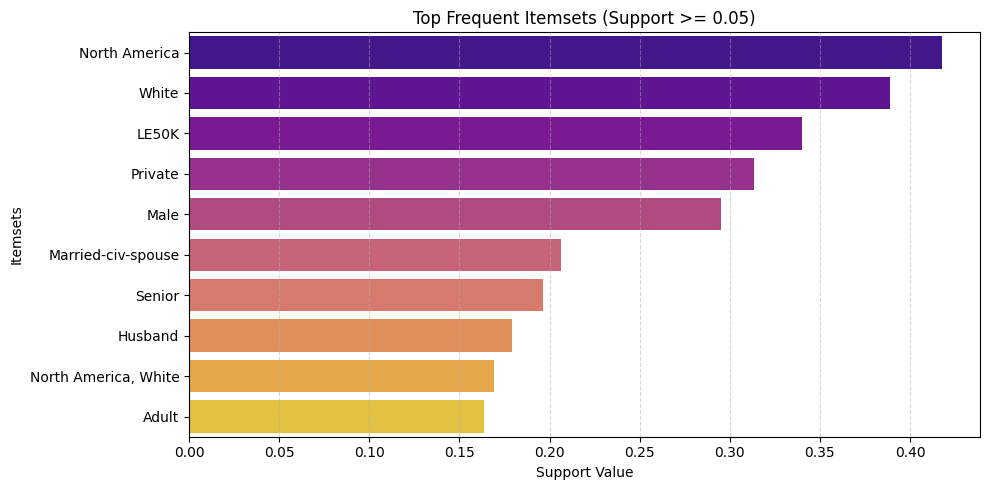

In [30]:
top_10_itemsets=frequent_itemsets.sort_values(by='support', ascending=False).head(10).copy()

# Convert itemsets frozenset type to string strings for clean plotting labels
top_10_itemsets['itemsets'] = top_10_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x='support', y='itemsets', data=top_10_itemsets, palette='plasma')
plt.title('Top Frequent Itemsets (Support >= 0.05)')
plt.xlabel('Support Value')
plt.ylabel('Itemsets')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()